# Lab 04: The Scaling Relation That Depends on How You Fit It

**ASTR 457, Fall 2026, posted Thu Sep 24, due Wed Sep 30 by Noon (fork → PR, as always)**

**Extra credit, +5 points on this lab:** if you attended Charlotte Ward's Sep 22 Astronomy Colloquium, turn in at least a page of notes including two questions you had, as a text file in your `submissions/<netid>/` folder, by Noon Tue Sep 29.

*Why this lab: every scaling relation you will ever use ($M_{\rm BH}$–$\sigma$, Tully–Fisher, the mass–metallicity relation, the SN Ia standardization) was fit by someone who chose a regression method, and the choice changes the published slope. Knowing when ordinary least squares lies, by how much, and what to do instead is how you read those papers, and how you referee them.*

Every one of you has your own dataset: `data/<your netid>.csv`, a sample of dwarf
galaxies hosting active galactic nuclei, selected by their optical variability in the
style of Ward et al. (2022, arXiv:2110.13098). Dwarf-galaxy AGN are one of the few
windows we have on black holes in the $10^5$–$10^7\,M_\odot$ range, where the seeds of
supermassive black holes hide. Columns:

- `logMstar`, `err_logMstar`: $x = \log_{10}(M_*/M_\odot)$, the host stellar mass from
  SED fitting, and its $1\sigma$ uncertainty (0.2–0.4 dex; dwarf-galaxy photometry is hard),
- `logMBH`, `err_logMBH`: $y = \log_{10}(M_{\rm BH}/M_\odot)$, the virial black-hole
  mass from broad-line spectroscopy, and its $1\sigma$ uncertainty.

The relation you are after is

$$y = \alpha\,(x - 9.5) + \beta + \text{intrinsic scatter } \sigma_{\rm int},$$

pivoted at $M_* = 10^{9.5} M_\odot$ so $\alpha$ and $\beta$ don't fight each other. **Both
variables have measurement error, and the relation has real astrophysical scatter on top.**
I know your true $\alpha$, $\beta$, and $\sigma_{\rm int}$. You don't, your classmates'
values are different from yours, and so are your sample sizes.

**How this is graded.** Not on whether your code runs, but on whether your answers are
*right* and your uncertainties are *honest*. Part of your grade comes from how close your
reported $\alpha$ and $\beta$ are to your truth **in units of your own reported
uncertainty**. Tiny error bars you can't back up lose points; padded ones lose points too.
Calibration is the skill. The floor under "padded": your reported $\sigma_\alpha$ may not
exceed **3× the curvature uncertainty of your own generative fit** from Part 2 (if your
Hessian turns out singular, quote a profile-likelihood width instead and say so). Bigger
than that is not caution, since it's an estimator you should have discarded.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and document
it in Part 4. You may be selected to defend this lab in person. Welcome to doing research.

## Part 1: The fit everyone does first (15%)

Load your sample and plot it with error bars **on both axes**. Then fit the relation the
way most papers still do: **ordinary least squares** on $y$ vs $(x - 9.5)$, every point
weighted equally, errors ignored. Build the design matrix and solve the normal equations
yourself (lecture machinery, or `np.polyfit` if you must, but know what it's doing). Report
$\hat\alpha \pm \sigma$ using the standard OLS variance estimate, $s^2 (A^{\mathsf T}A)^{-1}$
with $s^2 = \mathrm{RSS}/(N-2)$ (residual-scaled; the errors play no role yet, on purpose).

Then answer, in a few sentences: which of OLS's assumptions does *your* dataset violate?
For the slope specifically, which way does the bias from the $x$-errors pull, and what
controls its size? (We named it in lecture on Sep 24. The effect is *supposed*
to be there; understanding exactly why, on your own data, is the point of this lab.)

In [106]:
#imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
from scipy import stats, odr
from scipy.optimize._numdiff import approx_derivative

In [107]:
# Part 1: your work here
data = np.genfromtxt(f'data_04.csv', delimiter=',', names=True)
star, err_star, MBH, err_MBH = data['logMstar'],data['err_logMstar'],data['logMBH'],data['err_logMBH']

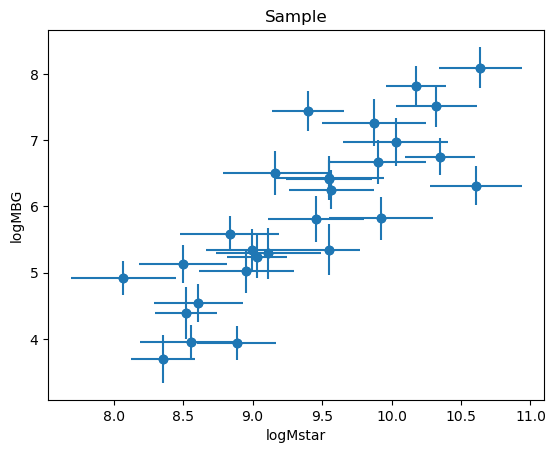

In [108]:
plt.plot(star, MBH,'o')
plt.errorbar(star, MBH, xerr=err_star, yerr=err_MBH, fmt='o', color='C0')
plt.title('Sample'),plt.xlabel('logMstar'),plt.ylabel('logMBG')
plt.show()

In [109]:
#OLS
def ols(A,y):
    n = len(y)
    AtA_inv = np.linalg.inv(A.T @ A)
    theta = AtA_inv @ A.T @ y
    resid = y - (A @ theta)
    s2 = resid @ (resid / n - A.shape[1])
    return theta, s2 * AtA_inv, resid

A = np.vstack([np.ones_like(star - 9.5), star - 9.5]).T
theta, cov, resid = ols(A, MBH)

B, a = theta
a_err = np.sqrt(np.diag(cov))[1]

print(f'alpha = {a:.4f} +/- {a_err:.4f}')

alpha = 1.4128 +/- 0.1805


In [110]:
#np.polyfit comparison
fit, cov_fit = np.polyfit((star - 9.5), MBH, 1, cov=True)

A = fit[0]
A_err = np.sqrt(np.diag(cov_fit))[0]

print(f'np.polyfit alpha = {A:.4f} +/- {A_err:.4f}')

np.polyfit alpha = 1.4128 +/- 0.1873


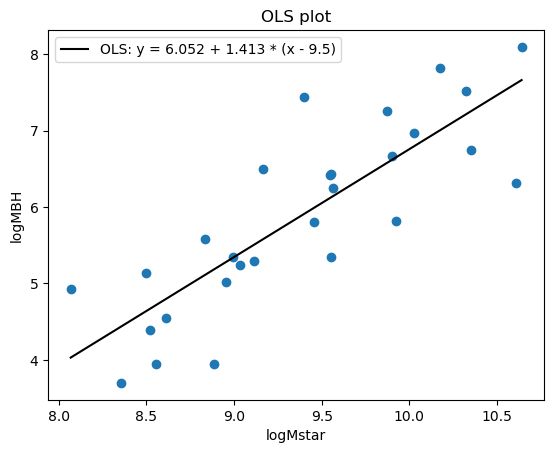

In [111]:
xfit = np.linspace(np.min(star), np.max(star), 500)
yfit = a * (xfit - 9.5) + B


plt.plot(star, MBH,'o')
plt.plot(xfit, yfit, color='k',label=f'OLS: y = {B:.3f} + {a:.3f} * (x - 9.5)')

plt.title('OLS plot'),plt.xlabel('logMstar'),plt.ylabel('logMBH')
plt.legend()
plt.show()

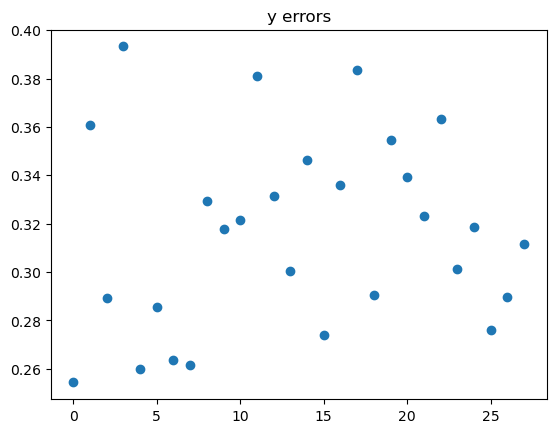

In [112]:
plt.plot(err_MBH,'o')
plt.title('y errors')
plt.show()

**ANSWER (a few sentences):** *In a few sentences: which of OLS's assumptions does your dataset violate? For the slope specifically, which way does the bias from the x-errors pull, and what controls its size?*

OLS assumes three things: Gaussian y uncertainties, exact x values, and independent errors for all points. My data violates all three of these assumptions. Because of this, the bias of the x-errors pulls the slope down, making it shallower. The size is controlled by the scatter (greater scatter -> larger error).

## Part 2: Estimators you can defend (40%)

Now fit the relation **three more ways** and compare:

1. **Weighted least squares** using the $y$-errors only:
   $\hat{\theta} = (A^{\mathsf T}\Sigma^{-1}A)^{-1}A^{\mathsf T}\Sigma^{-1}y$ with
   $\Sigma = \mathrm{diag}(\sigma_{y,i}^2)$, parameter covariance
   $(A^{\mathsf T}\Sigma^{-1}A)^{-1}$. Does weighting fix the Part 1 bias? Why or why not?

2. **Orthogonal distance regression** (`scipy.odr`, which warns that it is deprecated on
   import; that is fine in the course environment), which knows about the $x$-errors.
   Read what it minimizes before you run it. What does ODR assume about scatter
   *perpendicular to the relation*, and is that assumption true here?

3. **The generative model, honestly.** Write down where each data point comes from:
   the true stellar masses are drawn from the population,
   $x_i^{\rm true} \sim \mathcal{N}(\mu, \sigma_{\rm pop}^2)$; the relation plus intrinsic scatter
   makes the true BH mass; and your measurement errors corrupt both. Marginalizing over
   the (unobservable) true masses makes each observed pair $(x_i, y_i)$ a **bivariate
   Gaussian**:

   $$\begin{pmatrix} x_i \\ y_i \end{pmatrix} \sim \mathcal{N}\!\left[
   \begin{pmatrix} \mu \\ \alpha(\mu - 9.5) + \beta \end{pmatrix},\;
   \begin{pmatrix} \sigma_{\rm pop}^2 + \sigma_{x,i}^2 & \alpha\,\sigma_{\rm pop}^2 \\
   \alpha\,\sigma_{\rm pop}^2 & \alpha^2\sigma_{\rm pop}^2 + \sigma_{\rm int}^2 + \sigma_{y,i}^2 \end{pmatrix}
   \right]$$

   (Convince yourself of the three variance entries before you code; the off-diagonal
   covariance is what removes the attenuation bias. This is the Gaussian core of Kelly 2007, the paper behind
   every modern `linmix`-style fit.) Maximize the summed log-likelihood over all five
   parameters $(\alpha, \beta, \sigma_{\rm int}, \mu, \sigma_{\rm pop})$, and get uncertainties from
   the curvature of the log-likelihood at its peak (the observed information), and say so.

Make **one plot with all four fitted lines overplotted** on your data. They will not agree.
Explain, estimator by estimator, *why* each lands where it does, and which ingredient of the
data each one ignores.

Commit to a **final answer**: one $\alpha \pm \sigma$, $\beta \pm \sigma$, and
$\sigma_{\rm int} \pm \sigma$ you'd put in a paper, and justify the choice. Remember the
3× rule from the header.

In [113]:
# Part 2: your work here
#WLS
def wls(A,y,err):
    n = len(y)
    w = 1.0 / (err**2)
    AtwA_inv = np.linalg.inv(A.T @ (A * w[:, None]))
    theta = AtwA_inv @ A.T @ (y * w)
    return theta, AtwA_inv

A2 = np.vstack([np.ones_like(star - 9.5), star - 9.5]).T
theta2, cov2 = wls(A2, MBH, err_MBH)

B2, a2 = theta2
B_err2, a_err2 = np.sqrt(np.diag(cov2))

print(f'alpha = {a2:.4f} +/- {a_err2:.4f}')
print(f'beta = {B2:.4f} +/- {B_err2:.4f}')

alpha = 1.3556 +/- 0.0809
beta = 6.0477 +/- 0.0598


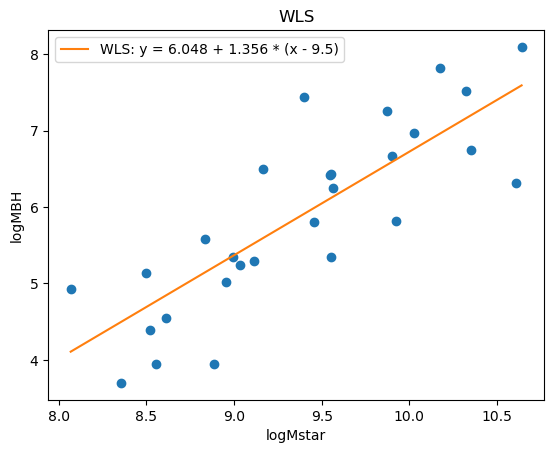

In [114]:
xfit = np.linspace(np.min(star), np.max(star), 500)
yfit3 = a2 * (xfit - 9.5) + B2

plt.plot(star, MBH,'o')
plt.plot(xfit, yfit3,label=f'WLS: y = {B2:.3f} + {a2:.3f} * (x - 9.5)')

plt.title('WLS'),plt.xlabel('logMstar'),plt.ylabel('logMBH')
plt.legend()
plt.show()

In [115]:
#ORD 
x = star - 9.5

def f(B, x):
    return B[0] * x + B[1]

_odr = odr.ODR(odr.RealData(x, MBH, sx=err_star), odr.Model(f), beta0 = [a, B])
odr_out = _odr.run()

a_odr, B_odr = odr_out.beta
err_a_odr, err_B_odr = odr_out.sd_beta
print(f'alpha = {a_odr:.4f} +/- {err_a_odr:.4f}')
print(f'beta = {B_odr:.4f} +/- {err_B_odr:.4f}')

alpha = 1.5429 +/- 0.1922
beta = 6.0625 +/- 0.1341


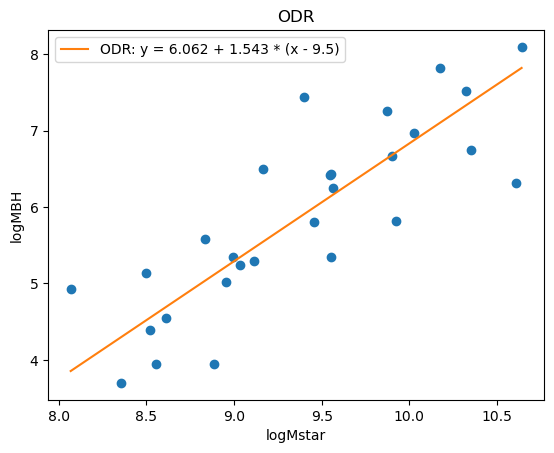

In [116]:
yfit2 = a_odr * (xfit - 9.5) + B_odr

plt.plot(star, MBH,'o')
plt.plot(xfit, yfit2,label=f'ODR: y = {B_odr:.3f} + {a_odr:.3f} * (x - 9.5)')

plt.title('ODR'),plt.xlabel('logMstar'),plt.ylabel('logMBH')
plt.legend()
plt.show()

In [117]:
#generative model
def neglogL(p, x=star, y=MBH, sx=err_star, sy=err_MBH):
    a, B, sig_int, u, sig_pop = p
    sint2, t2 = np.exp(2 * sig_int), np.exp(2 * sig_pop)
    dx, dy = x - u, y - (a * (u - 9.5) + B)
    s11 = t2 + sx**2
    s22 = a**2 * t2 + sint2 + sy**2
    s12 = a * t2
    det = s11 * s22 - s12**2
    quad = ((s22 * dx**2) - 2 * s12 * dx * dy + (s11 * dy**2)) / det
    return np.sum(np.log(det) + quad)

s = [a, B, 0.4, star.mean(), np.log(star.std())]
gen = minimize(neglogL, s, method = 'Nelder-Mead')
gen_f = gen.x

H = approx_derivative(lambda p: approx_derivative(lambda q: neglogL(q),p,method='3-point'),gen_f,method='3-point')

cov = np.linalg.inv(H)
sig = np.sqrt(np.diag(cov))

a_gen, B_gen = gen_f[0:2]
a_gen_err, B_gen_err = sig[0:2]

sig_int = np.exp(gen_f[2])
sig_int_err = sig[2]

print(f'alpha = {a_gen:.4f} +/- {a_gen_err:.4f}')
print(f'beta = {B_gen:.4f} +/- {B_gen_err:.4f}')
print(f'intristic scatter = {sig_int:.4f} +/- {sig_int_err:.4f}')

alpha = 1.7943 +/- 0.1870
beta = 6.0857 +/- 0.0989
intristic scatter = 0.3460 +/- 0.3919


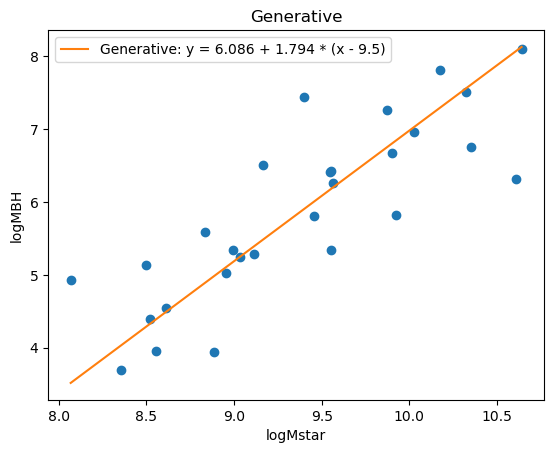

In [118]:
yfit4 = a_gen * (xfit - 9.5) + B_gen

plt.plot(star, MBH,'o')
plt.plot(xfit, yfit4,label=f'Generative: y = {B_gen:.3f} + {a_gen:.3f} * (x - 9.5)')

plt.title('Generative'),plt.xlabel('logMstar'),plt.ylabel('logMBH')
plt.legend()
plt.show()

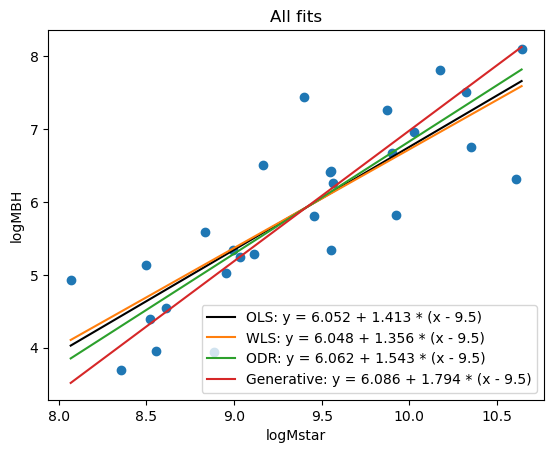

In [119]:
#all fits
xfit = np.linspace(np.min(star), np.max(star), 500)
yfit = a * (xfit - 9.5) + B

yfit2 = a_odr * (xfit - 9.5) + B_odr
yfit3 = a2 * (xfit - 9.5) + B2
yfit4 = a_gen * (xfit - 9.5) + B_gen


plt.plot(star, MBH,'o')
plt.plot(xfit, yfit, color='k',label=f'OLS: y = {B:.3f} + {a:.3f} * (x - 9.5)')
plt.plot(xfit, yfit3,label=f'WLS: y = {B2:.3f} + {a2:.3f} * (x - 9.5)')
plt.plot(xfit, yfit2,label=f'ODR: y = {B_odr:.3f} + {a_odr:.3f} * (x - 9.5)')
plt.plot(xfit, yfit4,label=f'Generative: y = {B_gen:.3f} + {a_gen:.3f} * (x - 9.5)')

plt.title('All fits'),plt.xlabel('logMstar'),plt.ylabel('logMBH')
plt.legend()
plt.show()

**FINAL ANSWER:** $\alpha = $ 1.7943 $\pm$ 0.1870 , $\beta = $ 6.0857 $\pm$ 0.0989 , $\sigma_{\rm int} = $ 0.3460 $\pm$ 0.3919 dex

**Justification and uncertainty method (a short paragraph):**

I chose to go with my estimated values of the generative model. With the uncertainties from the Hessian. In comparison, it is the least biased of the four estimators. OLS is biased by the x-errors and thus has a shallower slope. WLS only accounts for the y-errors, resulting in its slope being pulled the lowest of the four. ODR assumes the data has no instristic scatter, which products a steeper slope compared to OLS and WLS. The generative model is able to properly account for these blind spots.

## Part 3: The verification plan, written first and then executed (35%)

**Before you run anything below, write the plan** (3a). A verification plan you invent
after seeing the results is a rationalization.

**3a. The plan.** List the checks you will run to decide whether to trust your Part 2
numbers. At minimum, address:

1. **Closure**: simulate a dataset with a truth *you* choose (the generative recipe in
   Part 2 tells you exactly how) and confirm your fit recovers it.
2. **Bias and efficiency**: Monte Carlo all four estimators on many simulated datasets at
   plausible parameters. Plot each estimator's bias and variance for $\alpha$. This is
   *the* figure of this lab.
3. **Coverage**: across your simulations, do your 68% intervals contain the truth 68% of
   the time, for all three reported parameters?
4. **Sensitivity**: what happens to $\hat\alpha$ if the catalog $x$-errors are wrong by
   ±50% (generate correctly, fit with the mis-stated errors)? If the true population isn't Gaussian (try drawing $x^{\rm true}$ from a uniform
   distribution with the same mean and variance instead)? If you had assumed $\sigma_{\rm int} = 0$?

For **each** check, state *in advance* what failure would look like. A check that cannot
fail is not a check.

**3b. The execution.** Run the plan. Report what each check found, including anything that
failed or surprised you. A failed check honestly reported and diagnosed is worth more than
a wall of green checkmarks.

**VERIFICATION PLAN (write this before running 3b):**

1. I will simulate a dataset using random truth values and test it against my generative model to see if I recover those values.
   If I fail to recover those values, my generative model is likely not accurate on my dataset.
2. I will run all four estimators on several simulated datasets at plausible parameters and then plot the bias and variance for a. 
   If my chosen estimator contains more bias and variance in comparison to the others, it would suggest inaccuracy in my answer.
3. I will simulate several datasets using random truth values to see if my 68% intervals contain the truth 68% of the time.
   If my intervals do not contain the truth 68% of the time, my model may not be as accurrate as I thought.
4. I will set the x-errors to be half the current value and run my generative model.
   If the returned a changes drastically the estimator is likely more bias than expected.

In [120]:
# Part 3b: execute the plan here
#1
a_true, B_true, sigint_true, mu_true, sigpop_true = 2.7452, 8.3910, 0.5821, 10.3863, 0.3857
n = len(star)

rng_g = np.random.default_rng(92926)

xt = rng_g.normal(mu_true, sigpop_true, n)
yt = a_true * (xt - 9.5) + B_true + rng_g.normal(0, sigint_true, n)
xo = xt + rng_g.normal(0, err_star); yo = yt + rng_g.normal(0, err_MBH)
A_k = np.vstack([np.ones(n), xo - 9.5]).T
th_k = np.linalg.lstsq(A_k, yo, rcond=None)[0]
p_k = minimize(neglogL, [th_k[1], th_k[0], 0.4, xo.mean(), np.log(xo.std())], args=(xo, yo, err_star, err_MBH), method='Nelder-Mead').x

a_gen, B_gen = p_k[0:2]

sig_int = np.exp(p_k[2])

print(f'alpha = {a_gen:.4f}, difference = {np.abs(a_gen - a_true):.4f}')
print(f'beta = {B_gen:.4f}, difference = {np.abs(B_gen - B_true):.4f}')
print(f'intristic scatter = {sig_int:.4f}, difference = {np.abs(sig_int - sigint_true):.4f}')

alpha = 2.8615, difference = 0.1163
beta = 8.1883, difference = 0.2027
intristic scatter = 0.5940, difference = 0.0119


In [121]:
#2
rng = np.random.default_rng(92926)

a_true, B_true, log_sigint_true, mu_true, log_sigpop_true = gen_f
sigint_true = np.exp(log_sigint_true)
sigpop_true = np.exp(log_sigpop_true)

n = len(star)
nsim = 1000

a_ols = np.empty(nsim)
a_wls = np.empty(nsim)
a_odr = np.empty(nsim)
a_gen = np.empty(nsim)

for i in range(nsim):

    x_true = rng.normal(mu_true, sigpop_true, n)

    y_true = (
        a_true * (x_true - 9.5)
        + B_true
        + rng.normal(0, sigint_true, n)
    )

    x_obs = x_true + rng.normal(0, err_star)
    y_obs = y_true + rng.normal(0, err_MBH)


    A = np.vstack([np.ones(n), x_obs - 9.5]).T
    th_ols, _, _ = ols(A, y_obs)
    a_ols[i] = th_ols[1]


    th_wls, _ = wls(A, y_obs, err_MBH)
    a_wls[i] = th_wls[1]


    def f(beta, x):
        return beta[0] * x + beta[1]

    odr_fit = odr.ODR(
        odr.RealData(
            x_obs - 9.5,
            y_obs,
            sx=err_star,
            sy=err_MBH
        ),
        odr.Model(f),
        beta0=[th_ols[1], th_ols[0]]
    )

    odr_out = odr_fit.run()
    a_odr[i] = odr_out.beta[0]

    start = [
        th_ols[1],                  
        th_ols[0],                  
        np.log(0.3),                
        np.mean(x_obs),             
        np.log(np.std(x_obs))       
    ]

    gen_fit = minimize(
        neglogL,
        start,
        args=(x_obs, y_obs, err_star, err_MBH),
        method="Nelder-Mead"
    )

    a_gen[i] = gen_fit.x[0]

for name, vals in {
    "OLS": a_ols,
    "WLS": a_wls,
    "ODR": a_odr,
    "Generative": a_gen
}.items():

    bias = np.mean(vals) - a_true
    var = np.var(vals, ddof=1)

    print(f"{name:10s} bias = {bias:+.4f} variance = {var:.4e}")

OLS        bias = -0.3909 variance = 4.0402e-02
WLS        bias = -0.3907 variance = 4.1070e-02
ODR        bias = -0.3909 variance = 4.0402e-02
Generative bias = +0.0399 variance = 7.8360e-02


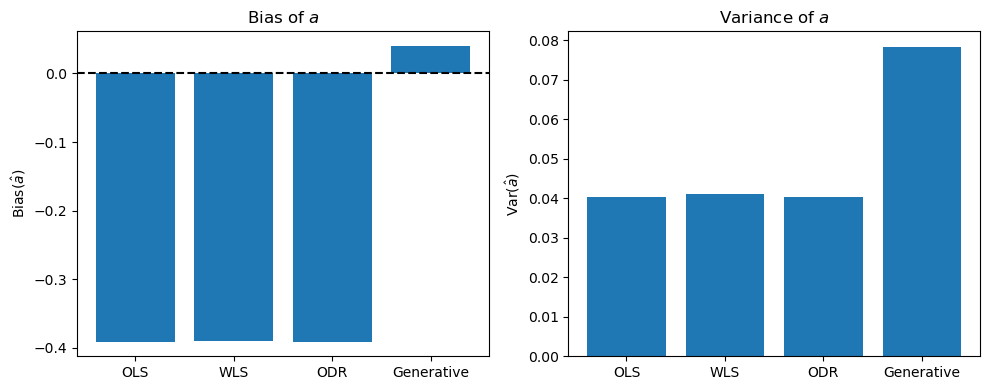

In [122]:
names = ["OLS", "WLS", "ODR", "Generative"]

biases = [
    np.mean(a_ols) - a_true,
    np.mean(a_wls) - a_true,
    np.mean(a_odr) - a_true,
    np.mean(a_gen) - a_true
]

variances = [
    np.var(a_ols, ddof=1),
    np.var(a_wls, ddof=1),
    np.var(a_odr, ddof=1),
    np.var(a_gen, ddof=1)
]

# Plot
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].bar(names, biases)
ax[0].axhline(0, color='k', linestyle='--')
ax[0].set_title('Bias of $a$')
ax[0].set_ylabel(r'Bias($\hat{a}$)')

ax[1].bar(names, variances)
ax[1].set_title('Variance of $a$')
ax[1].set_ylabel(r'Var($\hat{a}$)')

plt.tight_layout()
plt.show()

In [123]:
#3
inside = []

for _ in range(1000):
    xt = rng_g.normal(mu_true, sigpop_true, n)
    yt = a_true * (xt - 9.5) + B_true + rng_g.normal(0, sigint_true, n)

    xo = xt + rng_g.normal(0, err_star)
    yo = yt + rng_g.normal(0, err_MBH)

    A_k = np.vstack([np.ones(n), xo - 9.5]).T
    th_k = np.linalg.lstsq(A_k, yo, rcond=None)[0]

    res = minimize(neglogL,[th_k[1], th_k[0], 0.4, xo.mean(), np.log(xo.std())],args=(xo, yo, err_star, err_MBH),method="Nelder-Mead")

    if not res.success:
        continue

    p_k = res.x

    H = approx_derivative(lambda p: approx_derivative(lambda q: neglogL(q, xo, yo, err_star, err_MBH),p,method="3-point"),p_k,method="3-point")

    try:
        cov = np.linalg.inv(H)
    except np.linalg.LinAlgError:
        cov = np.linalg.pinv(H)

    sig = np.sqrt(np.maximum(np.diag(cov), 0))

    a = p_k[0]
    a_err = sig[0]

    contains_truth = (a_true >= a - a_err) and (a_true <= a + a_err)
    
    inside.append(contains_truth)

In [124]:
coverage = np.mean(inside)
print(coverage)

0.5226077812828601


In [125]:
#4
def neglogL(p, x=star, y=MBH, sx=err_star/2, sy=err_MBH):
    a, B, sig_int, u, sig_pop = p
    sint2, t2 = np.exp(2 * sig_int), np.exp(2 * sig_pop)
    dx, dy = x - u, y - (a * (u - 9.5) + B)
    s11 = t2 + sx**2
    s22 = a**2 * t2 + sint2 + sy**2
    s12 = a * t2
    det = s11 * s22 - s12**2
    quad = ((s22 * dx**2) - 2 * s12 * dx * dy + (s11 * dy**2)) / det
    return np.sum(np.log(det) + quad)

s = [a, B, 0.4, star.mean(), np.log(star.std())]
gen = minimize(neglogL, s, method = 'Nelder-Mead')
gen_f = gen.x

H = approx_derivative(lambda p: approx_derivative(lambda q: neglogL(q),p,method='3-point'),gen_f,method='3-point')

cov = np.linalg.inv(H)
sig = np.sqrt(np.diag(cov))

a_gen, B_gen = gen_f[0:2]
a_gen_err, B_gen_err = sig[0:2]

sig_int = np.exp(gen_f[2])
sig_int_err = sig[2]

print(f'alpha = {a_gen:.4f} +/- {a_gen_err:.4f}')
print(f'beta = {B_gen:.4f} +/- {B_gen_err:.4f}')
print(f'intristic scatter = {sig_int:.4f} +/- {sig_int_err:.4f}')

alpha = 1.4863 +/- 0.1386
beta = 6.0599 +/- 0.0925
intristic scatter = 0.5544 +/- 0.1381


**WHAT THE CHECKS FOUND:**

1. My generative model was able to recover my decided truth values from my simulated dataset within a reasonable range. This suggests good performance from it.
2. & 3. The generative model has much lower bias compared to the other estimators, but higher variance. This alongside it recovering the truth 52% of the time rather than 68% of the time suggests less accuracy than expected.
4. Halving the x-errors returned a, B, and intristic scatter that was lower. This is to be expected of the model taking all aspects into account.

## Part 4: AI-use appendix (10%)

**AI use**: which tools did you use (Copilot, Claude, ChatGPT, none, ...), for what,
what did they get wrong, and how did you catch it? Honesty is graded; "I didn't use any"
is fine if true.

**AI-USE APPENDIX:**

For this lab I used Copilot primarily for code troubleshooting. There were a couple times in part 2 where my code was returning numbers that did not make sense or errors I could not parse. So I asked Copilot what the potential problems could be. For part 2.3 I got coding help for calculating the Hessian and asked the model to explain the method. For part 3 I used code from Copilot for the bias and variance check. Along with correcting a code error in my 3rd check.